<a href="https://colab.research.google.com/github/chuyuezhang2-cmd/Assignment-1-ZHANG-Chuyue/blob/main/Financial_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDS527 Big Data Analytics 2025-2026 Term 2
## 1 Data Loading, Cleaning, Basic Visualization & Fixed Split

In [1]:
# Install PySpark
!pip install pyspark wordcloud matplotlib seaborn -q

### 1.1 Create Spark Session

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("CDS527_Task1_zcy_DataLoading") \
    .getOrCreate()

spark

### 1.2 Load Dataset

In [3]:
from google.colab import files
import io

# Upload the data file (run this cell and choose data6Financial.csv)
uploaded = files.upload()

# Read CSV
df = spark.read.csv(list(uploaded.keys())[0],
                    header=True,
                    inferSchema=True)

df.printSchema()
df.show(5, truncate=False)

Saving data6Financial.csv to data6Financial (1).csv
root
 |-- PhraseId: integer (nullable = true)
 |-- SentenceId: integer (nullable = true)
 |-- Phrase: string (nullable = true)
 |-- Sentiment: integer (nullable = true)

+--------+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|PhraseId|SentenceId|Phrase                                                                                                                                                                             |Sentiment|
+--------+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|110715  |5866      |` In this poor remake of such a well loved classic , Parker exposes the limitations of his skill and the basic flaws in h

### 1.3 Data Cleaning

In [4]:
from pyspark.sql.functions import col, trim, lower, regexp_replace

# 1. Drop rows with null in Phrase or Sentiment
df_clean = df.dropna(subset=["Phrase", "Sentiment"])

# 2. Text standardization: lower case + remove extra spaces + keep only letters/numbers
df_clean = df_clean.withColumn("Phrase", trim(lower(col("Phrase"))))
df_clean = df_clean.withColumn("Phrase",
                               regexp_replace(col("Phrase"), r'[^a-z0-9\s]', ''))

df_clean = df_clean.select("PhraseId", "SentenceId", "Phrase", "Sentiment")
df_clean.show(5, truncate=False)
print(f"Original rows: {df.count()}, After cleaning: {df_clean.count()}")

+--------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|PhraseId|SentenceId|Phrase                                                                                                                                                                           |Sentiment|
+--------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+
|110715  |5866      | in this poor remake of such a well loved classic  parker exposes the limitations of his skill and the basic flaws in his vision                                                 |0        |
|135234  |7302      |without any redeeming value whatsoever                                                                                                     

### 1.4 Basic EDA - Sentiment Distribution

/tmp/ipykernel_6138/3356593595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_dist, x="Sentiment", y="count", palette="viridis")


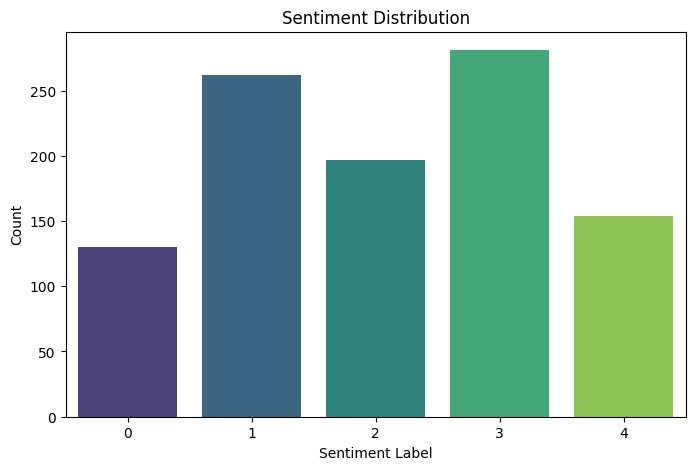

,Sentiment,count
0,0,130
1,1,262
2,2,197
3,3,281
4,4,154


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count distribution
sentiment_dist = df_clean.groupBy("Sentiment").count().orderBy("Sentiment").toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_dist, x="Sentiment", y="count", palette="viridis")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

sentiment_dist

### 1.5 Basic EDA - Sentence Length Statistics

+-------+-----------------+
|summary|       word_count|
+-------+-----------------+
|  count|             1024|
|   mean|        19.171875|
| stddev|9.640444597787528|
|    min|                1|
|    max|               51|
+-------+-----------------+

Q1: 11.0, Median: 18.0, Q3: 25.0


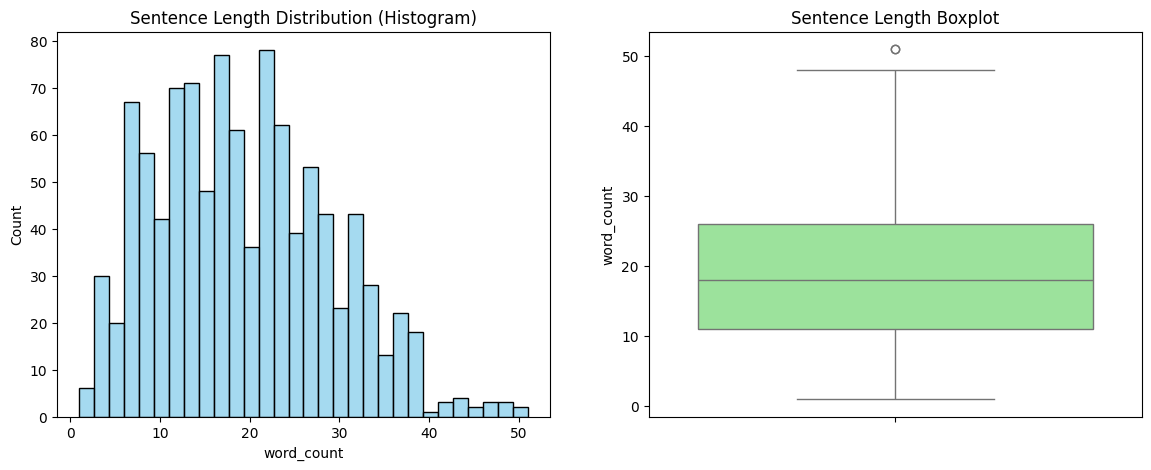

In [7]:
from pyspark.sql.functions import size, split

# Add word count column
df_len = df_clean.withColumn("word_count", size(split(col("Phrase"), " ")))

# Statistics
df_len.select("word_count").describe().show()

# Quartiles
quartiles = df_len.approxQuantile("word_count", [0.25, 0.5, 0.75], 0.01)
print(f"Q1: {quartiles[0]}, Median: {quartiles[1]}, Q3: {quartiles[2]}")

# Convert to Pandas for plotting
pdf_len = df_len.select("word_count").toPandas()

# Histogram + Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(pdf_len["word_count"], bins=30, ax=axes[0], color="skyblue")
axes[0].set_title("Sentence Length Distribution (Histogram)")
sns.boxplot(y=pdf_len["word_count"], ax=axes[1], color="lightgreen")
axes[1].set_title("Sentence Length Boxplot")
plt.show()

### 1.6 Basic EDA - Overall Word Cloud

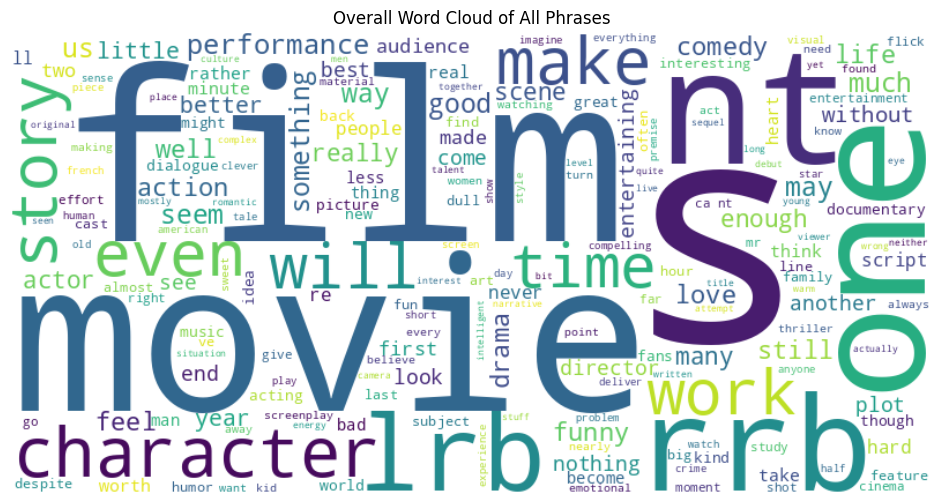

In [8]:
from wordcloud import WordCloud

# Collect all text
all_text = " ".join(df_clean.select("Phrase").rdd.flatMap(lambda x: x).collect())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white", max_words=200).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Overall Word Cloud of All Phrases")
plt.show()

### 1.7 Fixed Train/Test Split (80/20, seed=42)
**Important: All later models must use this exact split!**

In [9]:
# Fixed split with seed=42
(train_data, test_data) = df_clean.randomSplit([0.8, 0.2], seed=42)

print(f"Train rows: {train_data.count()}")
print(f"Test rows: {test_data.count()}")

# Optional: cache them for later use
train_data.cache()
test_data.cache()

Train rows: 855
Test rows: 169


DataFrame[PhraseId: int, SentenceId: int, Phrase: string, Sentiment: int]

### 1.8 Define Unified Evaluation Function
**All models in the group must use this function to compute Accuracy + Weighted F1**

In [10]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

def evaluate_model(predictions_df, label_col="Sentiment", prediction_col="prediction"):
    """
    predictions_df: must have columns [label_col, prediction_col]
    Returns: accuracy, weighted_f1, and prints confusion matrix
    """
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=prediction_col,
        metricName="accuracy")

    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=prediction_col,
        metricName="weightedFMeasure")

    accuracy = evaluator_acc.evaluate(predictions_df)
    weighted_f1 = evaluator_f1.evaluate(predictions_df)

    print(f"Accuracy = {accuracy:.4f}")
    print(f"Weighted F1-score = {weighted_f1:.4f}")

    # Confusion Matrix
    results_rdd = predictions_df.select(prediction_col, label_col).rdd.map(lambda row: (float(row[0]), float(row[1])))
    metrics = MulticlassMetrics(results_rdd)
    cm = metrics.confusionMatrix().toArray()
    print("\nConfusion Matrix:")
    print(cm)

    return accuracy, weighted_f1

### 1.9 Save Train/Test for Group Use (Optional but Recommended)

In [11]:
# You can save them as parquet so other members can load directly with same split
train_data.write.mode("overwrite").parquet("train_data")
test_data.write.mode("overwrite").parquet("test_data")
print("Train and test data saved as parquet.")

Train and test data saved as parquet.
